In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ============================================================
# 1. Paths
# ============================================================

INPUT_PATH = Path("../data/processed/neutral_scoring_prepared/neutral_scoring_input_v1.tsv")

OUTPUT_DIR = Path("../results/directional_neutral_scoring_results_v3")
OUTPUT_DIR.mkdir(exist_ok=True)

SCORED_OUTPUT = OUTPUT_DIR / "directional_neutral_deviation_scores_v3.tsv"
THRESHOLD_OUTPUT = OUTPUT_DIR / "directional_neutral_deviation_thresholds_v3.tsv"
ENRICHMENT_OUTPUT = OUTPUT_DIR / "directional_posthoc_group_enrichment_v3.tsv"
TOP100_OUTPUT = OUTPUT_DIR / "top_100_directional_score_v3.tsv"
COMPONENT_SUMMARY_OUTPUT = OUTPUT_DIR / "directional_score_components_summary_v3.tsv"

# ============================================================
# 2. Load input
# ============================================================

df = pd.read_csv(INPUT_PATH, sep="\t", low_memory=False)

print("Input shape:", df.shape)

print("\nAnalysis group distribution:")
print(df["analysis_group"].value_counts(dropna=False))

Input shape: (49704, 40)

Analysis group distribution:
analysis_group
unlabeled_or_other            41280
neutral_reference              8284
article_pathogenic_posthoc       84
disease_suspected_posthoc        56
Name: count, dtype: int64


In [3]:
# ============================================================
# 3. Required columns
# ============================================================

id_cols = [
    "variant_id",
    "position",
    "reference",
    "alternate",
]

label_cols = [
    "validation_label",
    "is_neutral_dataset8",
    "is_pathogenic_dataset9",
    "is_disease_suspected_dataset3",
    "analysis_group",
]

required_feature_cols = [
    "mlc_score",
    "pop_af_max",
    "pop_af_hom_max",
]

required_cols = id_cols + label_cols + required_feature_cols

missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

work = df.copy()

for col in required_feature_cols:
    work[col] = pd.to_numeric(work[col], errors="coerce")

missing_summary = work[required_feature_cols].isna().sum()
missing_summary = missing_summary[missing_summary > 0]

if len(missing_summary) > 0:
    raise ValueError(f"Missing values in required features:\n{missing_summary}")

In [4]:
# ============================================================
# 4. Directional score v3 components
# ============================================================

eps = 1e-6

# Main variant-specific component
work["mlc_component_raw"] = work["mlc_score"]

# Soft rarity component
# AF=0 now gives 6, not 12.
work["rarity_soft_raw"] = -np.log10(work["pop_af_max"] + eps)
work["rarity_soft_raw"] = work["rarity_soft_raw"].clip(lower=0, upper=6)

# Homoplasmic population signal absence
work["no_homoplasmic_component_raw"] = (
    work["pop_af_hom_max"] == 0
).astype(int)

component_cols = [
    "mlc_component_raw",
    "rarity_soft_raw",
    "no_homoplasmic_component_raw",
]

neutral_mask = work["analysis_group"] == "neutral_reference"

print("\nNeutral reference size:")
print(neutral_mask.sum())

print("\nRaw component summary among neutral reference:")
print(work.loc[neutral_mask, component_cols].describe())


Neutral reference size:
8284

Raw component summary among neutral reference:
       mlc_component_raw  rarity_soft_raw  no_homoplasmic_component_raw
count        8284.000000      8284.000000                   8284.000000
mean            0.122318         4.222938                      0.298165
std             0.221858         1.377778                      0.457480
min             0.000000         0.004060                      0.000000
25%             0.000000         3.184344                      0.000000
50%             0.000000         4.047689                      0.000000
75%             0.154117         6.000000                      1.000000
max             1.000000         6.000000                      1.000000


In [5]:
# ============================================================
# 5. Standardize components relative to neutral_reference
# ============================================================

scaler = StandardScaler()
scaler.fit(work.loc[neutral_mask, component_cols])

z = pd.DataFrame(
    scaler.transform(work[component_cols]),
    columns=[
        "mlc_component_z",
        "rarity_soft_z",
        "no_homoplasmic_component_z",
    ],
    index=work.index,
)

work = pd.concat([work, z], axis=1)

print("\nZ-component summary:")
print(
    work[
        [
            "mlc_component_z",
            "rarity_soft_z",
            "no_homoplasmic_component_z",
        ]
    ].describe()
)


Z-component summary:
       mlc_component_z  rarity_soft_z  no_homoplasmic_component_z
count     49704.000000   49704.000000                49704.000000
mean          1.384933       0.899774                    1.021717
std           1.500432       0.705680                    0.926124
min          -0.551369      -3.063264                   -0.651795
25%          -0.099070       0.719721                    1.534225
50%           1.314400       1.289881                    1.534225
75%           2.686760       1.289881                    1.534225
max           3.956299       1.289881                    1.534225


In [6]:
# ============================================================
# 6. Weighted directional score v3
# ============================================================

weights = {
    "mlc_component_z": 0.70,
    "rarity_soft_z": 0.25,
    "no_homoplasmic_component_z": 0.05,
}

work["directional_score_v3"] = 0.0

for col, weight in weights.items():
    work["directional_score_v3"] += weight * work[col]

work["directional_score_v3_rank"] = (
    work["directional_score_v3"]
    .rank(method="min", ascending=False)
    .astype(int)
)

work["directional_score_v3_percentile"] = (
    work["directional_score_v3"]
    .rank(method="average", pct=True)
)

print("\nDirectional score v3 summary:")
print(work["directional_score_v3"].describe())

print("\nDirectional score v3 summary by analysis_group:")
print(
    work
    .groupby("analysis_group")["directional_score_v3"]
    .describe()
)


Directional score v3 summary:
count    49704.000000
mean         1.245482
std          1.158164
min         -1.183571
25%          0.191470
50%          1.241141
75%          2.238389
max          3.168591
Name: directional_score_v3, dtype: float64

Directional score v3 summary by analysis_group:
                              count          mean       std       min  \
analysis_group                                                          
article_pathogenic_posthoc     84.0  1.599640e+00  0.842872 -0.266267   
disease_suspected_posthoc      56.0  1.072824e+00  1.026550 -0.430756   
neutral_reference            8284.0  1.646840e-16  0.782740 -1.183571   
unlabeled_or_other          41280.0  1.494937e+00  1.056160 -1.128441   

                                 25%       50%       75%       max  
analysis_group                                                      
article_pathogenic_posthoc  1.039595  1.583855  2.366733  2.955667  
disease_suspected_posthoc   0.230965  0.894431  1.91846

In [7]:
# ============================================================
# 7. Thresholds based on neutral_reference
# ============================================================

threshold_rows = []

neutral_scores = work.loc[neutral_mask, "directional_score_v3"]

for q in [0.90, 0.95, 0.99]:
    threshold_name = f"T{int(q * 100)}"
    threshold = neutral_scores.quantile(q)

    flag_col = f"directional_score_v3_above_{threshold_name}"

    work[flag_col] = (
        work["directional_score_v3"] > threshold
    ).astype(int)

    threshold_rows.append({
        "score_name": "directional_score_v3",
        "threshold_name": threshold_name,
        "neutral_quantile": q,
        "threshold_value": threshold,
        "n_neutral_above_threshold": int(work.loc[neutral_mask, flag_col].sum()),
        "fraction_neutral_above_threshold": float(work.loc[neutral_mask, flag_col].mean()),
    })

threshold_df = pd.DataFrame(threshold_rows)

print("\nThresholds:")
print(threshold_df)

threshold_df.to_csv(THRESHOLD_OUTPUT, sep="\t", index=False)

print("\nSaved thresholds:")
print(THRESHOLD_OUTPUT)


Thresholds:
             score_name threshold_name  neutral_quantile  threshold_value  \
0  directional_score_v3            T90              0.90         1.177818   
1  directional_score_v3            T95              0.95         1.775369   
2  directional_score_v3            T99              0.99         2.814295   

   n_neutral_above_threshold  fraction_neutral_above_threshold  
0                        829                          0.100072  
1                        415                          0.050097  
2                         83                          0.010019  

Saved thresholds:
../results/directional_neutral_scoring_results_v3/directional_neutral_deviation_thresholds_v3.tsv


In [8]:
# ============================================================
# 8. Post-hoc enrichment
# ============================================================

posthoc_groups = [
    "neutral_reference",
    "unlabeled_or_other",
    "article_pathogenic_posthoc",
    "disease_suspected_posthoc",
]

expected_fraction = {
    "T90": 0.10,
    "T95": 0.05,
    "T99": 0.01,
}

enrichment_rows = []

for threshold_name in ["T90", "T95", "T99"]:
    flag_col = f"directional_score_v3_above_{threshold_name}"
    expected = expected_fraction[threshold_name]

    for group in posthoc_groups:
        group_mask = work["analysis_group"] == group

        n_group = int(group_mask.sum())
        n_above = int(work.loc[group_mask, flag_col].sum())

        frac_above = n_above / n_group if n_group > 0 else np.nan

        enrichment_rows.append({
            "score_name": "directional_score_v3",
            "threshold_name": threshold_name,
            "analysis_group": group,
            "n_group": n_group,
            "n_above_threshold": n_above,
            "fraction_above_threshold": frac_above,
            "expected_neutral_fraction": expected,
            "fold_enrichment_vs_neutral_expectation": (
                frac_above / expected if expected > 0 else np.nan
            ),
        })

enrichment_df = pd.DataFrame(enrichment_rows)

print("\nPost-hoc enrichment:")
print(enrichment_df)

enrichment_df.to_csv(ENRICHMENT_OUTPUT, sep="\t", index=False)

print("\nSaved enrichment:")
print(ENRICHMENT_OUTPUT)


Post-hoc enrichment:
              score_name threshold_name              analysis_group  n_group  \
0   directional_score_v3            T90           neutral_reference     8284   
1   directional_score_v3            T90          unlabeled_or_other    41280   
2   directional_score_v3            T90  article_pathogenic_posthoc       84   
3   directional_score_v3            T90   disease_suspected_posthoc       56   
4   directional_score_v3            T95           neutral_reference     8284   
5   directional_score_v3            T95          unlabeled_or_other    41280   
6   directional_score_v3            T95  article_pathogenic_posthoc       84   
7   directional_score_v3            T95   disease_suspected_posthoc       56   
8   directional_score_v3            T99           neutral_reference     8284   
9   directional_score_v3            T99          unlabeled_or_other    41280   
10  directional_score_v3            T99  article_pathogenic_posthoc       84   
11  directional_sc

In [9]:
# ============================================================
# 9. Save scored table
# ============================================================

output_cols = [
    "variant_id",
    "position",
    "reference",
    "alternate",
    "validation_label",
    "is_neutral_dataset8",
    "is_pathogenic_dataset9",
    "is_disease_suspected_dataset3",
    "analysis_group",

    "mlc_score",
    "pop_af_max",
    "pop_af_hom_max",

    "mlc_component_raw",
    "rarity_soft_raw",
    "no_homoplasmic_component_raw",

    "mlc_component_z",
    "rarity_soft_z",
    "no_homoplasmic_component_z",

    "directional_score_v3",
    "directional_score_v3_rank",
    "directional_score_v3_percentile",

    "directional_score_v3_above_T90",
    "directional_score_v3_above_T95",
    "directional_score_v3_above_T99",
]

work[output_cols].to_csv(SCORED_OUTPUT, sep="\t", index=False)

print("\nSaved scored table:")
print(SCORED_OUTPUT)


Saved scored table:
../results/directional_neutral_scoring_results_v3/directional_neutral_deviation_scores_v3.tsv


In [10]:
# ============================================================
# 10. Top-100 variants for manual inspection
# ============================================================

top_100 = (
    work[output_cols]
    .sort_values("directional_score_v3", ascending=False)
    .head(100)
)

top_100.to_csv(TOP100_OUTPUT, sep="\t", index=False)

print("\nSaved top 100:")
print(TOP100_OUTPUT)

print("\nTop 30 variants:")
print(
    top_100[
        [
            "variant_id",
            "analysis_group",
            "directional_score_v3",
            "mlc_score",
            "pop_af_max",
            "rarity_soft_raw",
            "no_homoplasmic_component_raw",
            "directional_score_v3_above_T95",
            "directional_score_v3_above_T99",
        ]
    ].head(30)
)


Saved top 100:
../results/directional_neutral_scoring_results_v3/top_100_directional_score_v3.tsv

Top 30 variants:
       variant_id      analysis_group  directional_score_v3  mlc_score  \
14525   m.4843C>G   neutral_reference              3.168591        1.0   
11057   m.3687C>G  unlabeled_or_other              3.168591        1.0   
10969   m.3658T>A  unlabeled_or_other              3.168591        1.0   
10972   m.3659G>A  unlabeled_or_other              3.168591        1.0   
20204   m.6736T>G  unlabeled_or_other              3.168591        1.0   
10981   m.3662C>A  unlabeled_or_other              3.168591        1.0   
10987   m.3664G>A  unlabeled_or_other              3.168591        1.0   
20195   m.6733T>G  unlabeled_or_other              3.168591        1.0   
10996   m.3667T>A  unlabeled_or_other              3.168591        1.0   
10999   m.3668G>A  unlabeled_or_other              3.168591        1.0   
11017   m.3674C>A  unlabeled_or_other              3.168591        1.

In [11]:
## ============================================================
# 11. Component summary by group
# ============================================================

summary_rows = []

component_summary_cols = [
    "mlc_score",
    "pop_af_max",
    "pop_af_hom_max",

    "mlc_component_raw",
    "rarity_soft_raw",
    "no_homoplasmic_component_raw",

    "mlc_component_z",
    "rarity_soft_z",
    "no_homoplasmic_component_z",

    "directional_score_v3",
]

for group in posthoc_groups:
    group_df = work[work["analysis_group"] == group]

    for col in component_summary_cols:
        summary_rows.append({
            "analysis_group": group,
            "feature": col,
            "n": int(group_df[col].notna().sum()),
            "mean": float(group_df[col].mean()),
            "median": float(group_df[col].median()),
            "q25": float(group_df[col].quantile(0.25)),
            "q75": float(group_df[col].quantile(0.75)),
            "min": float(group_df[col].min()),
            "max": float(group_df[col].max()),
        })

component_summary = pd.DataFrame(summary_rows)

component_summary.to_csv(
    COMPONENT_SUMMARY_OUTPUT,
    sep="\t",
    index=False,
)

print("\nSaved component summary:")
print(COMPONENT_SUMMARY_OUTPUT)


Saved component summary:
../results/directional_neutral_scoring_results_v3/directional_score_components_summary_v3.tsv


In [12]:
import matplotlib.pyplot as plt
import numpy as np

analysis_group_order = [
    "neutral_reference",
    "unlabeled_or_other",
    "article_pathogenic_posthoc",
    "disease_suspected_posthoc",
]

analysis_group_labels = {
    "neutral_reference": "Neutral reference",
    "unlabeled_or_other": "Unlabeled / other",
    "article_pathogenic_posthoc": "Article pathogenic post-hoc",
    "disease_suspected_posthoc": "Disease suspected post-hoc",
}

def plot_score_v3_distribution(work, threshold_df):
    score_col = "directional_score_v3"

    plt.figure(figsize=(10, 6))

    for group in analysis_group_order:
        subset = work.loc[
            work["analysis_group"] == group,
            score_col
        ].dropna()

        if len(subset) == 0:
            continue

        plt.hist(
            subset,
            bins=60,
            density=True,
            alpha=0.45,
            label=f"{analysis_group_labels[group]} (n={len(subset)})",
        )

    for threshold_name in ["T90", "T95", "T99"]:
        threshold_value = threshold_df.loc[
            threshold_df["threshold_name"] == threshold_name,
            "threshold_value"
        ].iloc[0]

        plt.axvline(
            threshold_value,
            linestyle="--",
            linewidth=1,
            label=threshold_name,
        )

    plt.xlabel("Directional score v3")
    plt.ylabel("Density")
    plt.title("Directional score v3 distribution by group")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_enrichment_v3(enrichment_df, threshold_name):
    plot_df = enrichment_df[
        enrichment_df["threshold_name"] == threshold_name
    ].copy()

    plot_df = (
        plot_df
        .set_index("analysis_group")
        .loc[analysis_group_order]
        .reset_index()
    )

    x = np.arange(plot_df.shape[0])
    y = plot_df["fraction_above_threshold"].values

    plt.figure(figsize=(9, 5))

    plt.bar(x, y)

    plt.axhline(
        {"T90": 0.10, "T95": 0.05, "T99": 0.01}[threshold_name],
        linestyle="--",
        linewidth=1,
        label=f"Neutral expectation: {threshold_name}",
    )

    plt.xticks(
        x,
        [analysis_group_labels[g] for g in plot_df["analysis_group"]],
        rotation=30,
        ha="right",
    )

    plt.ylabel("Fraction above threshold")
    plt.title(f"Directional score v3: fraction above {threshold_name}")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_v3_components(work):
    component_cols = [
        "mlc_component_z",
        "rarity_soft_z",
        "no_homoplasmic_component_z",
    ]

    for col in component_cols:
        plt.figure(figsize=(10, 5))

        for group in analysis_group_order:
            subset = work.loc[
                work["analysis_group"] == group,
                col
            ].dropna()

            if len(subset) == 0:
                continue

            plt.hist(
                subset,
                bins=60,
                density=True,
                alpha=0.45,
                label=f"{analysis_group_labels[group]}",
            )

        plt.xlabel(col)
        plt.ylabel("Density")
        plt.title(f"Component distribution: {col}")
        plt.legend(fontsize=8)
        plt.tight_layout()
        plt.show()


def plot_v3_top_tail(work, threshold_df, top_n=1000):
    top_df = (
        work
        .sort_values("directional_score_v3", ascending=False)
        .head(top_n)
        .copy()
    )

    top_df["rank_in_top"] = np.arange(1, top_df.shape[0] + 1)

    plt.figure(figsize=(10, 5))

    plt.plot(
        top_df["rank_in_top"],
        top_df["directional_score_v3"],
        linewidth=1,
    )

    for threshold_name in ["T90", "T95", "T99"]:
        threshold_value = threshold_df.loc[
            threshold_df["threshold_name"] == threshold_name,
            "threshold_value"
        ].iloc[0]

        plt.axhline(
            threshold_value,
            linestyle="--",
            linewidth=1,
            label=threshold_name,
        )

    plt.xlabel(f"Rank among top {top_n} variants")
    plt.ylabel("Directional score v3")
    plt.title("Top-tail profile: directional score v3")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

In [13]:
# ============================================================
# 12. Notebook plotting helpers
# ============================================================

analysis_group_order = [
    "neutral_reference",
    "unlabeled_or_other",
    "article_pathogenic_posthoc",
    "disease_suspected_posthoc",
]

analysis_group_labels = {
    "neutral_reference": "Neutral reference",
    "unlabeled_or_other": "Unlabeled / other",
    "article_pathogenic_posthoc": "Article pathogenic post-hoc",
    "disease_suspected_posthoc": "Disease suspected post-hoc",
}

threshold_expected_fraction = {
    "T90": 0.10,
    "T95": 0.05,
    "T99": 0.01,
}


def plot_directional_score_distribution(scored, threshold_df, score_name):
    score_col = f"{score_name}_score"

    plt.figure(figsize=(10, 6))

    for group in analysis_group_order:
        subset = scored.loc[
            scored["analysis_group"] == group,
            score_col
        ].dropna()

        if len(subset) == 0:
            continue

        plt.hist(
            subset,
            bins=60,
            alpha=0.45,
            density=True,
            label=f"{analysis_group_labels[group]} (n={len(subset)})",
        )

    for threshold_name in ["T90", "T95", "T99"]:
        threshold_value = threshold_df.loc[
            (threshold_df["score_name"] == score_name)
            & (threshold_df["threshold_name"] == threshold_name),
            "threshold_value"
        ].iloc[0]

        plt.axvline(
            threshold_value,
            linestyle="--",
            linewidth=1,
            label=threshold_name,
        )

    plt.xlabel("Directional neutral-deviation score")
    plt.ylabel("Density")
    plt.title(f"Directional score distribution: {score_name}")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_directional_fraction_above(enrichment_df, score_name, threshold_name):
    plot_df = enrichment_df[
        (enrichment_df["score_name"] == score_name)
        & (enrichment_df["threshold_name"] == threshold_name)
    ].copy()

    plot_df["group_label"] = plot_df["analysis_group"].map(analysis_group_labels)

    plot_df = (
        plot_df
        .set_index("analysis_group")
        .loc[analysis_group_order]
        .reset_index()
    )

    x = np.arange(plot_df.shape[0])
    y = plot_df["fraction_above_threshold"].values

    plt.figure(figsize=(9, 5))
    plt.bar(x, y)

    plt.axhline(
        threshold_expected_fraction[threshold_name],
        linestyle="--",
        linewidth=1,
        label=f"Expected neutral fraction: {threshold_name}",
    )

    plt.xticks(
        x,
        plot_df["group_label"],
        rotation=30,
        ha="right",
    )

    plt.ylabel("Fraction above threshold")
    plt.title(f"Fraction above {threshold_name}: {score_name}")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_directional_top_tail(scored, threshold_df, score_name, top_n=1000):
    score_col = f"{score_name}_score"

    top_df = (
        scored
        .sort_values(score_col, ascending=False)
        .head(top_n)
        .copy()
    )

    top_df["rank_in_top"] = np.arange(1, top_df.shape[0] + 1)

    plt.figure(figsize=(10, 5))

    plt.plot(
        top_df["rank_in_top"],
        top_df[score_col],
        linewidth=1,
    )

    for threshold_name in ["T90", "T95", "T99"]:
        threshold_value = threshold_df.loc[
            (threshold_df["score_name"] == score_name)
            & (threshold_df["threshold_name"] == threshold_name),
            "threshold_value"
        ].iloc[0]

        plt.axhline(
            threshold_value,
            linestyle="--",
            linewidth=1,
            label=threshold_name,
        )

    plt.xlabel(f"Rank among top {top_n} variants")
    plt.ylabel("Directional neutral-deviation score")
    plt.title(f"Top-tail score profile: {score_name}")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_mlc_vs_directional_combined(scored):
    x_col = "mlc_score"
    y_col = "directional_combined_score"

    plt.figure(figsize=(8, 6))

    for group in analysis_group_order:
        subset = scored[scored["analysis_group"] == group]

        if subset.shape[0] == 0:
            continue

        if group == "unlabeled_or_other" and subset.shape[0] > 5000:
            subset = subset.sample(
                n=5000,
                random_state=42,
            )

        plt.scatter(
            subset[x_col],
            subset[y_col],
            s=8,
            alpha=0.5,
            label=analysis_group_labels[group],
        )

    plt.xlabel("mlc_score")
    plt.ylabel("Directional combined score")
    plt.title("mlc_score vs directional combined score")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

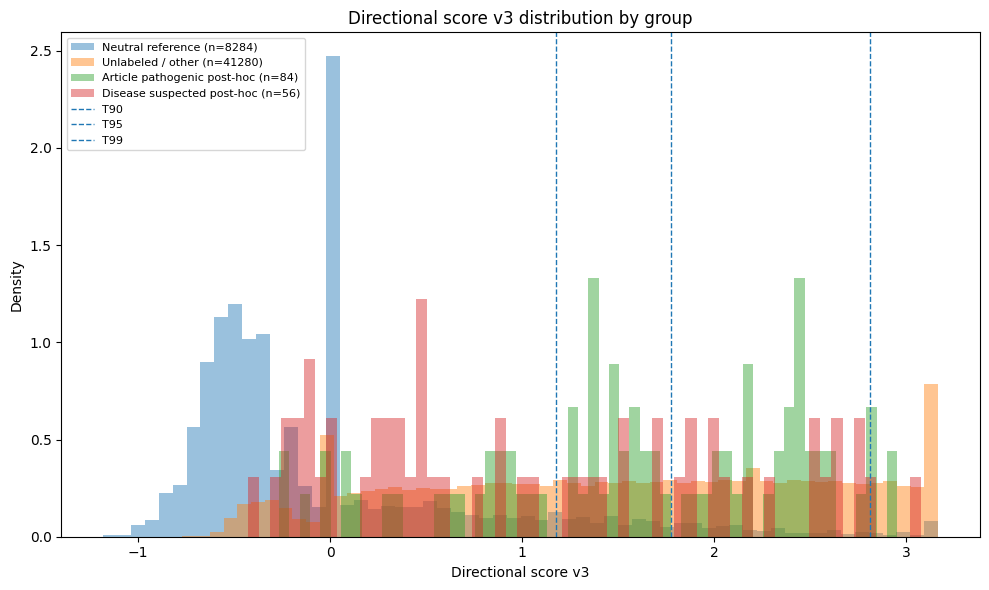

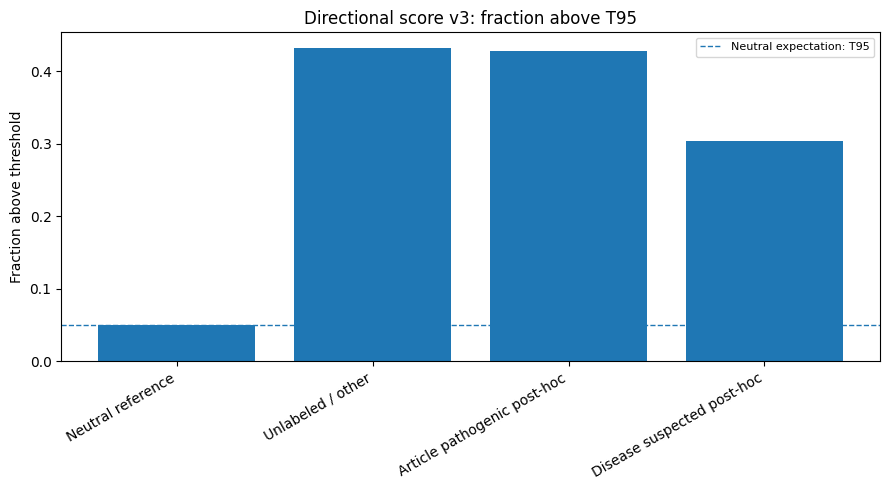

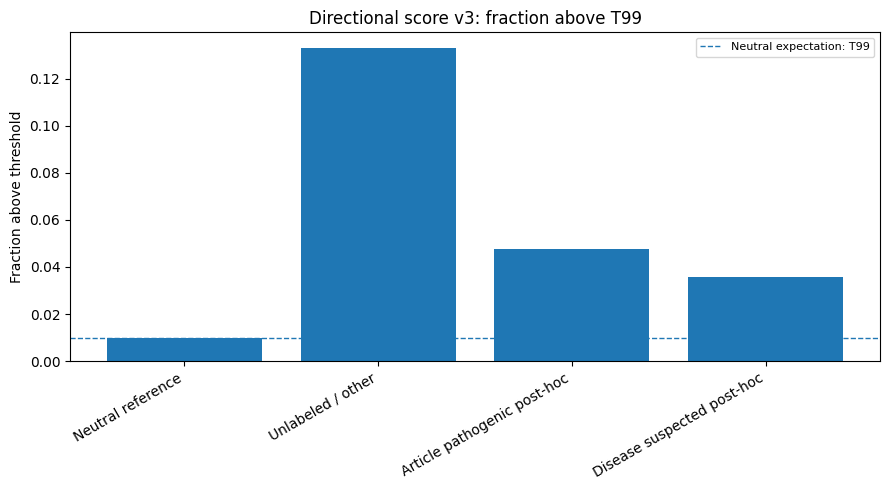

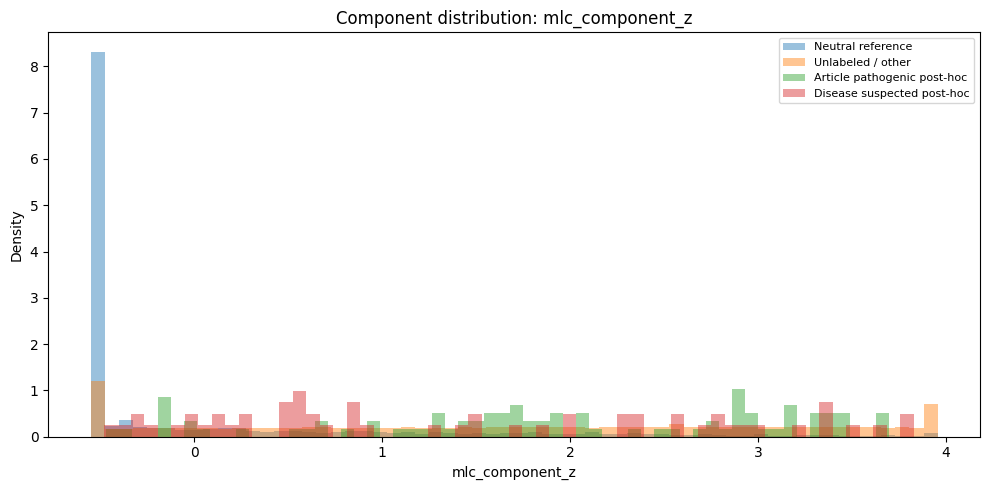

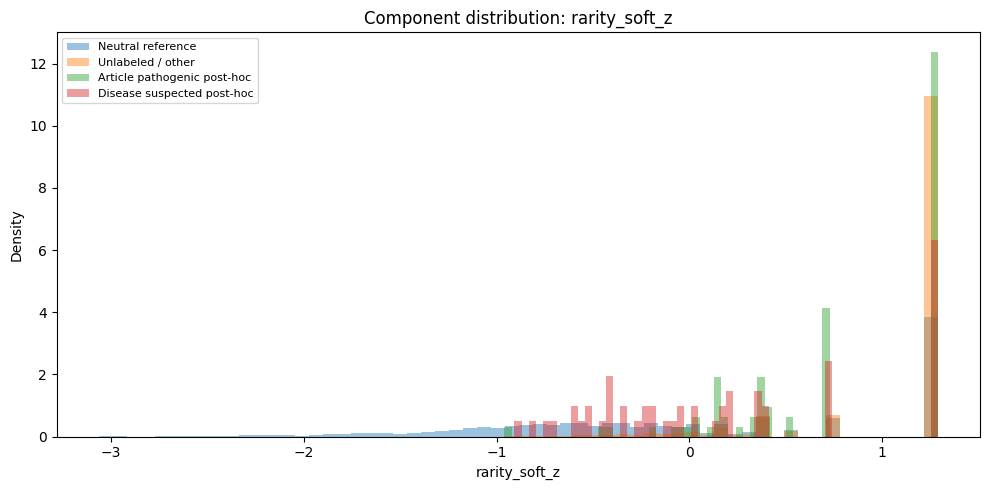

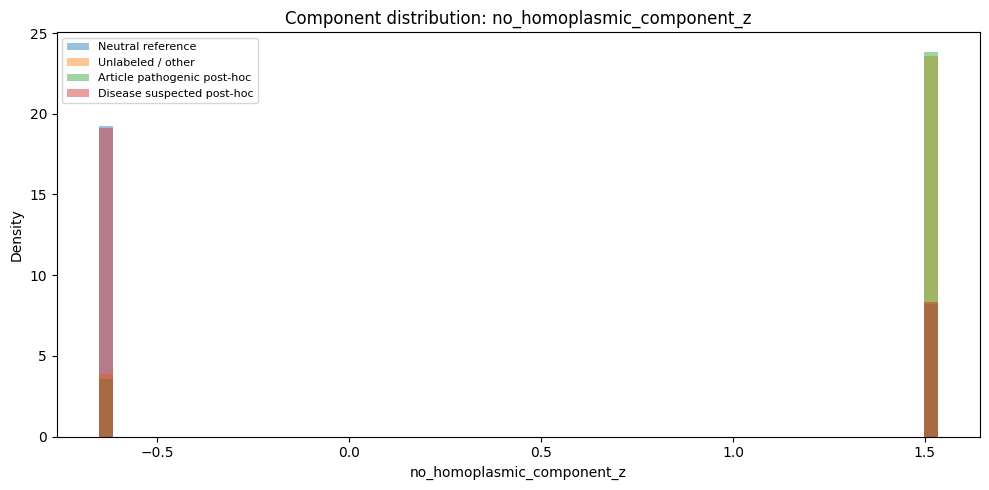

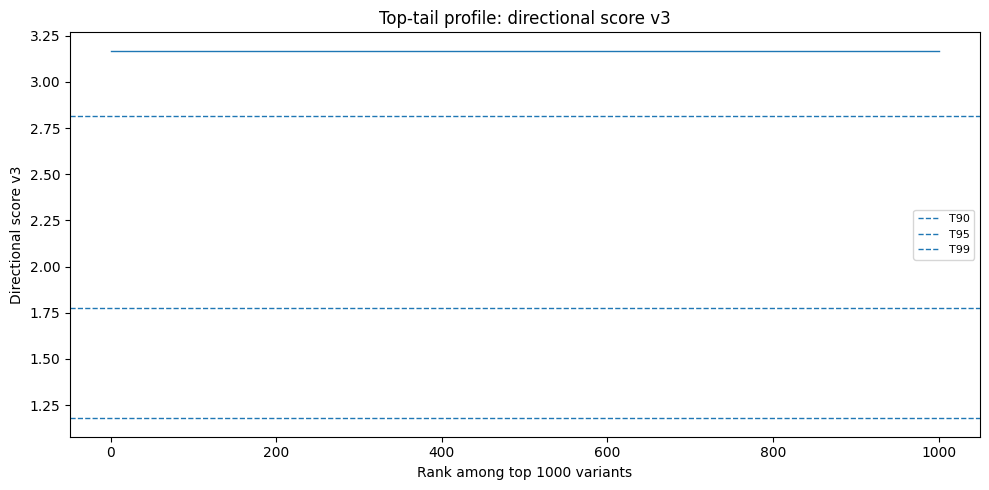

In [14]:
plot_score_v3_distribution(work, threshold_df)
plot_enrichment_v3(enrichment_df, "T95")
plot_enrichment_v3(enrichment_df, "T99")
plot_v3_components(work)
plot_v3_top_tail(work, threshold_df, top_n=1000)